In [3]:
import pandas as pd

base_path = '/Users/xinwenfan/Downloads/_defense/data/'

# 1. read data
df = pd.read_csv(base_path + 'mbaojin.csv', skiprows=[1])

# 2.screen scene
df_filtered = df[df['Scene'].isin([1])].copy()

# 3. target column to numeric, coercing errors to NaN
target_col = 'Channel_3_FITC-T3.IntensityMeanValue'
df_filtered[target_col] = pd.to_numeric(df_filtered[target_col], errors='coerce')

# 4. create GUV_ID and Col_Name for pivoting
df_filtered['GUV_ID'] = df_filtered.groupby(['Time', 'Scene']).cumcount() + 1
df_filtered['Col_Name'] = 'Scene' + df_filtered['Scene'].astype(int).astype(str) + '_GUV' + df_filtered['GUV_ID'].astype(str)

# 5. repivot the DataFrame to have Time as index and Col_Name as columns
df_pivot = df_filtered.pivot(index='Time', columns='Col_Name', values=target_col)

df_cleaned = df_pivot.dropna(axis=1, how='all')

# 7. sort columns by Scene and GUV number
def sort_key(col_name):
    parts = col_name.replace('Scene', '').split('_GUV')
    return int(parts[0]), int(parts[1])

sorted_columns = sorted(df_cleaned.columns, key=sort_key)
df_cleaned = df_cleaned[sorted_columns]


df_cleaned.to_csv(base_path + 'filtered_cleaned.csv')

### plot

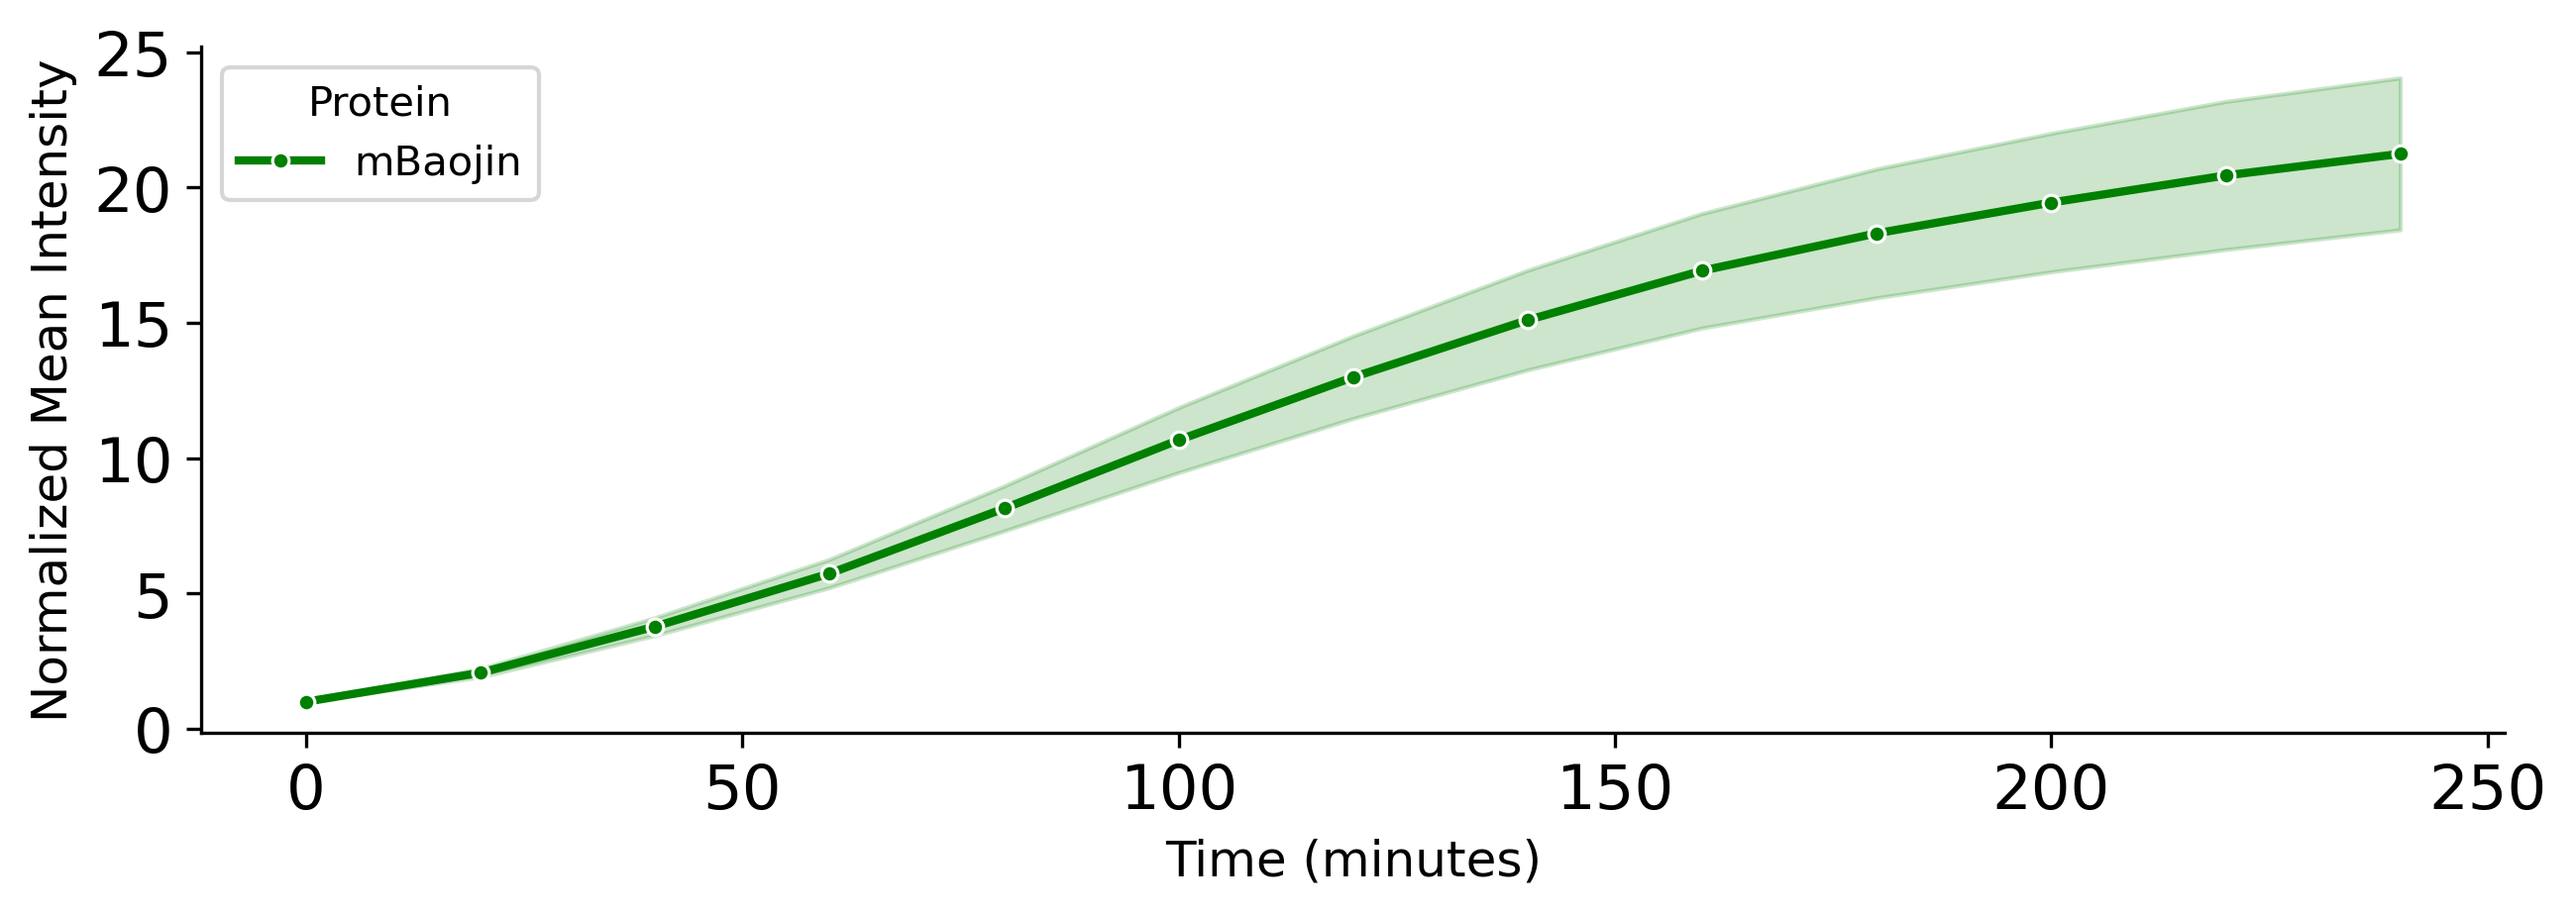

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


base_path = '/Users/xinwenfan/Downloads/_defense/data/'

files = {
    'mBaojin': 'filtered_cleaned.csv',
    #'SN7+mscarlet': 'filtered_SN7-mscarlet_cleaned.csv',
    #'SN31+mscarlet': 'filtered_SN31-mscarlet_cleaned.csv',
    #'SN32+mscarlet': 'filtered_SN32-mscarlet_cleaned.csv'
}

all_data = []

for label, filename in files.items():
    # read data and set Time as index
    df = pd.read_csv(base_path + filename, index_col='Time')
    
    # normalize each column by the value at Time=1
    df_norm = df.div(df.loc[1], axis=1)
    
    # reset index to make Time a column again for melting
    df_norm = df_norm.reset_index()
    
    # make a long format DataFrame suitable for seaborn
    df_melted = df_norm.melt(id_vars='Time', var_name='GUV', value_name='Normalized_Intensity')
    
    # add a column for the condition label
    df_melted['Protein'] = label
    
    all_data.append(df_melted)


combined_df = pd.concat(all_data, ignore_index=True)
combined_df['Time_min'] = (combined_df['Time'] - 1) * 20

plt.figure(figsize=(10, 3), dpi=300)

# seaborn.lineplot
sns.lineplot(
    data=combined_df,
    x='Time_min',               
    y='Normalized_Intensity',
    hue='Protein',
    palette=['green'],
    errorbar='se',        
    err_style='band',     
    marker='o',
    markersize=4,
    linewidth=2
)

sns.despine()

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Time (minutes)', fontsize=12)
plt.ylabel('Normalized Mean Intensity', fontsize=12)
#plt.title('Normalized Fluorescence Intensity Over Time with SEM Band', fontsize=14)
#plt.grid(True, linestyle='--', alpha=0.6)


#plt.savefig(base_path + 'normalized_plot_with_errorbars.png', dpi=300, bbox_inches='tight')
plt.show()